# Attribution & Incrementality

## Цель анализа

На предыдущем этапе мы обнаружили связь между маркетинговыми активностями
и динамикой продаж, однако эта связь не означает причинный эффект.

Теперь разделим анализ на две части:

1. **Attribution** — определим, каким маркетинговым касаниям можно формально
   приписать произошедшие продажи при разных правилах атрибуции.

2. **Incrementality** — попробуем приближённо оценить, сколько продаж произошло
   сверх ожидаемого естественного уровня спроса.

Важно: attribution показывает, как мы распределяем заслугу за продажу,
а incrementality пытается ответить на вопрос, произошла бы эта продажа без маркетинга.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
# Пути к исходным данным

SALES_PATH = Path("../data/raw/base.xlsx")
MARKETING_PATH = Path("../data/raw/marketing_history.xlsx")

In [4]:
# Загружаем продажи

sales = pd.read_excel(
    SALES_PATH,
    sheet_name="Данные"
)

sales = sales.rename(
    columns={
        "Номер студента": "student_id",
        "Сумма": "amount",
        "Курс": "course",
        "Время": "timestamp",
    }
)

sales["timestamp"] = pd.to_datetime(
    sales["timestamp"],
    errors="coerce"
)

sales.head()

,student_id,amount,course,timestamp
0,437,"8,950.00",ML про,2026-08-04 09:08:31
1,437,"7,890.00",Аналитика старт,2026-08-04 09:35:00
2,443,"8,475.00",Линейная алгебра,2026-08-04 10:14:38
3,443,"8,475.00",Мат анализ,2026-08-04 10:14:38
4,430,"8,950.00",К ВУЗу,2026-08-04 13:38:06


In [5]:
# Загружаем marketing history.
# В файле технические названия колонок находятся в третьей строке.

marketing = pd.read_excel(
    MARKETING_PATH,
    header=2
)

marketing["event_time"] = pd.to_datetime(
    marketing["event_time"],
    errors="coerce"
)

marketing.head()

,event_id,event_time,source_channel,activity_type,course,campaign,placement,creative_text,external_or_internal,post_url,views,reactions,cost_rub,data_source,confidence,collected_by,notes,channel_relationship,paid_status,raw_origin,raw_category,raw_period,raw_media,raw_forwarded_from,raw_links,raw_promo_candidate,raw_offer_flag,raw_discount_flag,raw_launch_flag,raw_lead_magnet_flag,raw_ad_marking,raw_erid,raw_scraped_at,raw_html_ref,Unnamed: 34,product_scope,product_line,inferred_course,content_direction,candidate_courses
0,INT-1764,2026-07-01 18:10:49,@postypashki_old,Контент с предложением курсов,ML старт | Data Science,NaN,postypashki_old/1764,Самые интересные события в ближайшее время.\nВсе подобное вы можете обсудить в комментариях под этим постом или в на...,internal,https://t.me/postypashki_old/1764,21200,42.00,NaN,Telegram,raw,Codex,Самые интересные события в ближайшее время. Все подобное вы можете обсудить в комментариях под этим постом или в наш...,internal,unknown,telegram_internal,Контент с предложением курсов,Предыстория,NaN,NaN,NaN,NaN,1.00,0.00,0.00,0.00,NaN,False,2026-07-01T15:10:49+00:00,NaN,NaN,multiple_courses,START,NaN,career,ML старт | Data science
1,INT-1765,2026-07-02 18:31:22,@postypashki_old,Прочий контент,NaN,NaN,postypashki_old/1765,"В новом ролике обсудим, что с вашей психикой сделает работа в Сбере и Иннотехе: рабство, кастрация и принуждение к.....",internal,https://t.me/postypashki_old/1765,17500,50.00,NaN,Telegram,raw,Codex,"В новом ролике обсудим, что с вашей психикой сделает работа в Сбере и Иннотехе: рабство, кастрация и принуждение к.....",internal,unknown,telegram_internal,Прочий контент,Предыстория,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,NaN,False,2026-07-02T15:31:22+00:00,NaN,NaN,unknown,NaN,NaN,career,NaN
2,INT-1767,2026-07-04 12:03:55,@postypashki_old,Промо со скидкой,NaN,NaN,postypashki_old/1767,❗️ Завтра заканчивается донабор на стажировку в Т-банк\n\nВ честь этого события объявляем скидку до 5 июля на наши к...,internal,https://t.me/postypashki_old/1767,18600,25.00,NaN,Telegram,raw,Codex,❗️ Завтра заканчивается донабор на стажировку в Т-банк В честь этого события объявляем скидку до 5 июля на наши карь...,internal,unknown,telegram_internal,Промо со скидкой,Предыстория,NaN,NaN,NaN,NaN,1.00,1.00,0.00,0.00,NaN,False,2026-07-04T09:03:55+00:00,NaN,NaN,product_line,START,NaN,career,Аналитика старт | Алгоритмы старт | Backend старт | ML старт
3,INT-1768,2026-07-04 15:35:53,@postypashki_old,Контент с предложением курсов,ML старт,NaN,postypashki_old/1768,Академия Авито и Буткем Авито \n\nСегодня прошел первый этап отбора в Академию Авито. За час мы решили все задачи и ...,internal,https://t.me/postypashki_old/1768,20400,26.00,NaN,Telegram,raw,Codex,Академия Авито и Буткем Авито Сегодня прошел первый этап отбора в Академию Авито. За час мы решили все задачи и разб...,internal,unknown,telegram_internal,Контент с предложением курсов,Предыстория,NaN,NaN,NaN,NaN,1.00,0.00,0.00,0.00,NaN,False,2026-07-04T12:35:53+00:00,NaN,NaN,single_course,START,ML старт,ml,ML старт
4,INT-1770,2026-07-05 16:51:14,@postypashki_old,Промо со скидкой,ML старт,NaN,postypashki_old/1770,"Как затащить МЛ собеседование в 2026 году \n\nВ вебинаре разобрали, что сегодня ждут от начинающего ML-специалиста: ...",internal,https://t.me/postypashki_old/1770,19000,36.00,NaN,Telegram,raw,Codex,"Как затащить МЛ собеседование в 2026 году В вебинаре разобрали, что сегодня ждут от начинающего ML-специалиста: каки...",internal,unknown,telegram_internal,Промо со скидкой,Предыстория,NaN,NaN,NaN,NaN,0.00,1.00,0.00,0.00,NaN,False,2026-07-05T13:51:14+00:00,NaN,NaN,single_course,START,ML старт,ml,ML старт


## 1. Построение attribution table

Для каждой продажи найдём маркетинговые касания,
которые произошли до покупки и относились к тому же курсу.

На этом этапе мы ещё не решаем, какое касание «получит» продажу.
Мы только строим таблицу возможных связей:

`продажа → предыдущие маркетинговые касания`

В дальнейшем на этой таблице можно применять разные модели атрибуции:
same-day, last-touch и различные attribution windows.

In [6]:
# Приводим названия некоторых курсов к формату,
# который используется в candidate_courses маркетингового реестра.

course_mapping = {
    "AI агенты": "AI-агенты про",
    "АВ тестам": "А/В-тесты",
}

sales["course_normalized"] = (
    sales["course"]
    .replace(course_mapping)
    .str.strip()
)

sales[
    ["course", "course_normalized"]
].drop_duplicates().sort_values("course_normalized")

,course,course_normalized
302,AI агенты,AI-агенты про
9,Backend про,Backend про
6,Backend старт,Backend старт
77,Data Engenering,Data Engenering
5,Data Science,Data Science
0,ML про,ML про
8,ML старт,ML старт
12,АВ тестам,А/В-тесты
40,Алгоритмы,Алгоритмы
230,Алгоритмы про,Алгоритмы про


In [7]:
# Каждая строка sales — отдельная транзакция.
# Создаём технический sale_id, чтобы потом можно было
# однозначно связывать продажу с маркетинговыми касаниями.

sales = sales.reset_index(drop=True)

sales["sale_id"] = (
    "SALE-" +
    (sales.index + 1)
    .astype(str)
    .str.zfill(4)
)

sales[
    [
        "sale_id",
        "student_id",
        "timestamp",
        "course_normalized",
        "amount",
    ]
].head()

,sale_id,student_id,timestamp,course_normalized,amount
0,SALE-0001,437,2026-08-04 09:08:31,ML про,"8,950.00"
1,SALE-0002,437,2026-08-04 09:35:00,Аналитика старт,"7,890.00"
2,SALE-0003,443,2026-08-04 10:14:38,Линейная алгебра,"8,475.00"
3,SALE-0004,443,2026-08-04 10:14:38,Мат анализ,"8,475.00"
4,SALE-0005,430,2026-08-04 13:38:06,К ВУЗу,"8,950.00"


### Единица анализа

На текущем этапе единицей является отдельная строка таблицы продаж —
то есть отдельная транзакция.

Для каждой транзакции создаётся технический `sale_id`.

In [8]:
# Одна маркетинговая активность может относиться сразу к нескольким курсам.
# Поэтому разделяем candidate_courses по символу "|"
# и получаем отдельную строку для каждой пары event × course.

marketing_courses = (
    marketing[
        [
            "event_id",
            "event_time",
            "activity_type",
            "external_or_internal",
            "product_scope",
            "product_line",
            "content_direction",
            "candidate_courses",
        ]
    ]
    .dropna(subset=["candidate_courses"])
    .assign(
        candidate_course=lambda x:
        x["candidate_courses"].str.split(r"\s*\|\s*")
    )
    .explode("candidate_course")
    .reset_index(drop=True)
)

marketing_courses["candidate_course"] = (
    marketing_courses["candidate_course"]
    .str.strip()
)

marketing_courses.head()

,event_id,event_time,activity_type,external_or_internal,product_scope,product_line,content_direction,candidate_courses,candidate_course
0,INT-1764,2026-07-01 18:10:49,Контент с предложением курсов,internal,multiple_courses,START,career,ML старт | Data science,ML старт
1,INT-1764,2026-07-01 18:10:49,Контент с предложением курсов,internal,multiple_courses,START,career,ML старт | Data science,Data science
2,INT-1767,2026-07-04 12:03:55,Промо со скидкой,internal,product_line,START,career,Аналитика старт | Алгоритмы старт | Backend старт | ML старт,Аналитика старт
3,INT-1767,2026-07-04 12:03:55,Промо со скидкой,internal,product_line,START,career,Аналитика старт | Алгоритмы старт | Backend старт | ML старт,Алгоритмы старт
4,INT-1767,2026-07-04 12:03:55,Промо со скидкой,internal,product_line,START,career,Аналитика старт | Алгоритмы старт | Backend старт | ML старт,Backend старт


In [9]:
# Проверяем, какие курсы присутствуют одновременно
# в продажах и в маркетинговом реестре.

sales_courses = set(
    sales["course_normalized"].dropna().unique()
)

marketing_candidate_courses = set(
    marketing_courses["candidate_course"].dropna().unique()
)

common_courses = sorted(
    sales_courses & marketing_candidate_courses
)

common_courses

['AI-агенты про',
 'Backend про',
 'Backend старт',
 'ML про',
 'ML старт',
 'А/В-тесты',
 'Алгоритмы про',
 'Алгоритмы старт',
 'Аналитика про',
 'Аналитика старт']

In [10]:
# Нам нет смысла атрибутировать маркетинг после окончания sales history.
# Оставляем маркетинговые события, которые произошли
# не позднее последней наблюдаемой продажи.

sales_start = sales["timestamp"].min()
sales_end = sales["timestamp"].max()

marketing_courses_overlap = marketing_courses[
    marketing_courses["event_time"] <= sales_end
].copy()

print("Начало продаж:", sales_start)
print("Конец продаж:", sales_end)
print("Маркетинговых event × course:", len(marketing_courses_overlap))

Начало продаж: 2026-08-04 09:08:31
Конец продаж: 2026-09-10 06:09:12
Маркетинговых event × course: 358


### Логика связи продажи и маркетинга

Маркетинговое событие считается потенциальным касанием продажи, если:

1. событие относится к тому же курсу;
2. событие произошло раньше момента покупки;
3. событие находится в выбранном lookback window.

Для базовой attribution table используем окно **7 дней до покупки**.

Это не означает, что маркетинг действительно вызвал продажу.
Окно лишь определяет набор событий, которые потенциально могли участвовать
в пути пользователя.

In [14]:
# Максимальное окно, в котором ищем возможные маркетинговые касания.
# В дальнейшем модели будут использовать более узкие окна:
# same-day, 1 день, 3 дня и т.д.

MAX_LOOKBACK_DAYS = 7

In [11]:
# Соединяем каждую продажу со всеми маркетинговыми событиями
# для того же курса.

attribution_candidates = sales[
    [
        "sale_id",
        "student_id",
        "timestamp",
        "course_normalized",
        "amount",
    ]
].merge(
    marketing_courses_overlap,
    left_on="course_normalized",
    right_on="candidate_course",
    how="left",
)

attribution_candidates.head()

,sale_id,student_id,timestamp,course_normalized,amount,event_id,event_time,activity_type,external_or_internal,product_scope,product_line,content_direction,candidate_courses,candidate_course
0,SALE-0001,437,2026-08-04 09:08:31,ML про,"8,950.00",INT-1818,2026-07-27 20:05:25,Контент с предложением курсов,internal,product_line,START | PRO,career,Аналитика старт | Алгоритмы старт | Backend старт | ML старт | AI-агенты про | Алгоритмы про | Аналитика про | ML пр...,ML про
1,SALE-0001,437,2026-08-04 09:08:31,ML про,"8,950.00",INT-1843,2026-08-11 18:50:13,Контент с предложением курсов,internal,product_line,PRO,career,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про,ML про
2,SALE-0001,437,2026-08-04 09:08:31,ML про,"8,950.00",INT-1852,2026-08-16 19:39:39,Контент с упоминанием,internal,product_line,PRO,career,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про,ML про
3,SALE-0001,437,2026-08-04 09:08:31,ML про,"8,950.00",INT-1859,2026-08-22 13:19:48,Запуск / набор,internal,multiple_courses,PRO,education,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про | А/В-тесты,ML про
4,SALE-0001,437,2026-08-04 09:08:31,ML про,"8,950.00",INT-1872,2026-08-29 21:58:58,Контент с предложением курсов,internal,multiple_courses,PRO,education,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про,ML про


In [12]:
# Считаем точное время между маркетинговым событием и покупкой.

attribution_candidates["time_since_touch"] = (
    attribution_candidates["timestamp"]
    - attribution_candidates["event_time"]
)

In [15]:
# Оставляем только события:
# 1. произошедшие не позже продажи;
# 2. находящиеся не более чем за 7 дней до продажи.

attribution_table = attribution_candidates[
    (attribution_candidates["time_since_touch"] >= pd.Timedelta(0)) &
    (
        attribution_candidates["time_since_touch"]
        <= pd.Timedelta(days=MAX_LOOKBACK_DAYS)
    )
].copy()

attribution_table.head()

,sale_id,student_id,timestamp,course_normalized,amount,event_id,event_time,activity_type,external_or_internal,product_scope,product_line,content_direction,candidate_courses,candidate_course,time_since_touch
12,SALE-0001,437,2026-08-04 09:08:31,ML про,"8,950.00",EXT-22,2026-07-29 20:11:23,Контент с упоминанием,external,product_line,PRO,career,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про,ML про,5 days 12:57:08
84,SALE-0007,131,2026-08-04 17:05:46,Backend старт,"8,745.00",INT-1824,2026-07-30 19:05:25,Контент с предложением курсов,internal,single_course,START,backend,Backend старт,Backend старт,4 days 22:00:21
124,SALE-0008,571,2026-08-04 17:19:52,ML про,"8,475.00",EXT-22,2026-07-29 20:11:23,Контент с упоминанием,external,product_line,PRO,career,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про,ML про,5 days 21:08:29
202,SALE-0010,159,2026-08-05 12:56:32,Backend про,"8,475.00",EXT-22,2026-07-29 20:11:23,Контент с упоминанием,external,product_line,PRO,career,AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про,Backend про,6 days 16:45:09
236,SALE-0011,159,2026-08-05 12:56:32,Backend старт,"8,475.00",INT-1824,2026-07-30 19:05:25,Контент с предложением курсов,internal,single_course,START,backend,Backend старт,Backend старт,5 days 17:51:07


In [16]:
# Дата продажи и дата маркетингового события

attribution_table["sale_date"] = (
    attribution_table["timestamp"].dt.floor("D")
)

attribution_table["touch_date"] = (
    attribution_table["event_time"].dt.floor("D")
)

In [17]:
# Разница между датами.
#
# 0 = событие и покупка в один календарный день
# 1 = событие было за день до покупки
# 2 = за два дня и т.д.

attribution_table["days_since_touch"] = (
    attribution_table["sale_date"]
    - attribution_table["touch_date"]
).dt.days

In [18]:
# Точная разница в часах может пригодиться,
# если позже захотим более строгую модель last-touch.

attribution_table["hours_since_touch"] = (
    attribution_table["time_since_touch"]
    .dt.total_seconds()
    / 3600
)

In [19]:
attribution_table = attribution_table[
    [
        "sale_id",
        "student_id",
        "timestamp",
        "sale_date",
        "course_normalized",
        "amount",

        "event_id",
        "event_time",
        "touch_date",
        "activity_type",
        "external_or_internal",
        "product_line",

        "days_since_touch",
        "hours_since_touch",
    ]
].sort_values(
    ["sale_id", "event_time"]
)

attribution_table.head(20)

,sale_id,student_id,timestamp,sale_date,course_normalized,amount,event_id,event_time,touch_date,activity_type,external_or_internal,product_line,days_since_touch,hours_since_touch
12,SALE-0001,437,2026-08-04 09:08:31,2026-08-04,ML про,"8,950.00",EXT-22,2026-07-29 20:11:23,2026-07-29,Контент с упоминанием,external,PRO,6,132.95
84,SALE-0007,131,2026-08-04 17:05:46,2026-08-04,Backend старт,"8,745.00",INT-1824,2026-07-30 19:05:25,2026-07-30,Контент с предложением курсов,internal,START,5,118.01
124,SALE-0008,571,2026-08-04 17:19:52,2026-08-04,ML про,"8,475.00",EXT-22,2026-07-29 20:11:23,2026-07-29,Контент с упоминанием,external,PRO,6,141.14
202,SALE-0010,159,2026-08-05 12:56:32,2026-08-05,Backend про,"8,475.00",EXT-22,2026-07-29 20:11:23,2026-07-29,Контент с упоминанием,external,PRO,7,160.75
236,SALE-0011,159,2026-08-05 12:56:32,2026-08-05,Backend старт,"8,475.00",INT-1824,2026-07-30 19:05:25,2026-07-30,Контент с предложением курсов,internal,START,6,137.85
316,SALE-0014,137,2026-08-05 15:01:16,2026-08-05,Backend старт,"8,475.00",INT-1824,2026-07-30 19:05:25,2026-07-30,Контент с предложением курсов,internal,START,6,139.93
395,SALE-0016,222,2026-08-05 18:52:56,2026-08-05,Backend про,"7,975.00",EXT-22,2026-07-29 20:11:23,2026-07-29,Контент с упоминанием,external,PRO,7,166.69
396,SALE-0016,222,2026-08-05 18:52:56,2026-08-05,Backend про,"7,975.00",EXT-31,2026-08-05 18:19:34,2026-08-05,Контент с предложением курсов,external,PRO,0,0.56
429,SALE-0017,222,2026-08-05 18:52:56,2026-08-05,Backend старт,"7,975.00",INT-1824,2026-07-30 19:05:25,2026-07-30,Контент с предложением курсов,internal,START,6,143.79
518,SALE-0030,481,2026-08-07 13:09:54,2026-08-07,ML про,"8,745.00",EXT-31,2026-08-05 18:19:34,2026-08-05,Контент с предложением курсов,external,PRO,2,42.84


### Что означает attribution table

Теперь одна продажа может встречаться в таблице несколько раз.

Например:

| sale_id | продажа | marketing event | days_since_touch |
|---|---|---|---|
| SALE-001 | 10 августа | пост 8 августа | 2 |
| SALE-001 | 10 августа | скидка 9 августа | 1 |
| SALE-001 | 10 августа | пост 10 августа | 0 |

Это означает, что перед одной продажей было несколько потенциальных
маркетинговых касаний.

Именно поэтому attribution требует отдельного правила:
нужно решить, как распределить одну продажу между этими событиями.

In [20]:
touches_per_sale = (
    attribution_table
    .groupby("sale_id", as_index=False)
    .agg(
        touches=("event_id", "nunique")
    )
)

touches_per_sale["touches"].describe()

count   576.00
mean      8.95
std       5.70
min       1.00
25%       4.00
50%       8.00
75%      15.00
max      20.00
Name: touches, dtype: float64

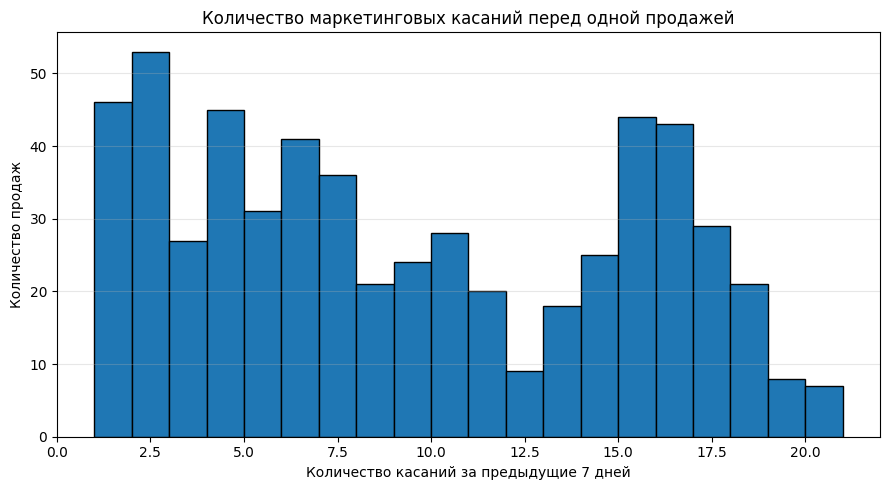

In [21]:
plt.figure(figsize=(9, 5))

plt.hist(
    touches_per_sale["touches"],
    bins=range(
        1,
        touches_per_sale["touches"].max() + 2
    ),
    edgecolor="black"
)

plt.title("Количество маркетинговых касаний перед одной продажей")
plt.xlabel("Количество касаний за предыдущие 7 дней")
plt.ylabel("Количество продаж")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Все уникальные продажи

total_sales = sales["sale_id"].nunique()

# Продажи, перед которыми найдено хотя бы одно маркетинговое касание

sales_with_touch = attribution_table["sale_id"].nunique()

sales_without_touch = total_sales - sales_with_touch

coverage = sales_with_touch / total_sales * 100

print(f"Всего продаж: {total_sales}")
print(f"Есть хотя бы одно касание за 7 дней: {sales_with_touch}")
print(f"Нет найденных касаний за 7 дней: {sales_without_touch}")
print(f"Attribution coverage: {coverage:.1f}%")

Всего продаж: 795
Есть хотя бы одно касание за 7 дней: 576
Нет найденных касаний за 7 дней: 219
Attribution coverage: 72.5%


In [23]:
# Берём несколько продаж, перед которыми было много касаний.

example_sale_ids = (
    touches_per_sale
    .sort_values("touches", ascending=False)
    .head(5)["sale_id"]
)

attribution_table[
    attribution_table["sale_id"].isin(example_sale_ids)
][
    [
        "sale_id",
        "timestamp",
        "course_normalized",
        "amount",
        "event_id",
        "event_time",
        "activity_type",
        "days_since_touch",
        "hours_since_touch",
    ]
]

,sale_id,timestamp,course_normalized,amount,event_id,event_time,activity_type,days_since_touch,hours_since_touch
6352,SALE-0221,2026-08-11 17:07:53,Алгоритмы старт,"4,950.00",INT-1833,2026-08-07 17:22:16,Контент с упоминанием,4,95.76
6365,SALE-0221,2026-08-11 17:07:53,Алгоритмы старт,"4,950.00",EXT-35,2026-08-08 12:24:53,Промо со скидкой,3,76.72
6367,SALE-0221,2026-08-11 17:07:53,Алгоритмы старт,"4,950.00",EXT-37,2026-08-08 13:34:46,Промо со скидкой,3,75.55
6368,SALE-0221,2026-08-11 17:07:53,Алгоритмы старт,"4,950.00",EXT-38,2026-08-08 15:29:40,Промо со скидкой,3,73.64
6366,SALE-0221,2026-08-11 17:07:53,Алгоритмы старт,"4,950.00",EXT-36,2026-08-08 16:40:01,Промо со скидкой,3,72.46
...,...,...,...,...,...,...,...,...,...
7166,SALE-0247,2026-08-13 09:51:23,Алгоритмы старт,"8,745.00",EXT-53,2026-08-10 21:49:44,Промо со скидкой,3,60.03
7165,SALE-0247,2026-08-13 09:51:23,Алгоритмы старт,"8,745.00",EXT-50,2026-08-10 21:55:16,Промо со скидкой,3,59.94
7164,SALE-0247,2026-08-13 09:51:23,Алгоритмы старт,"8,745.00",EXT-48,2026-08-10 22:02:01,Промо со скидкой,3,59.82
7158,SALE-0247,2026-08-13 09:51:23,Алгоритмы старт,"8,745.00",EXT-40,2026-08-10 22:29:02,Промо со скидкой,3,59.37


### Вывод по attribution coverage

Из 795 наблюдаемых продаж для 576 (72.5%) удалось найти хотя бы одно
маркетинговое касание по тому же курсу за предыдущие 7 дней.

Это означает, что значительная часть продаж может быть включена
в историческую модель атрибуции.

Однако наличие касания не означает, что именно оно вызвало покупку.

В среднем перед одной продажей, имеющей маркетинговые касания,
наблюдается около 9 событий, медиана составляет 8 событий,
а для 25% таких продаж найдено 15 и более касаний.

Таким образом, большинство продаж нельзя однозначно связать
с одним конкретным маркетинговым событием.

Высокая плотность касаний делает результат атрибуции сильно зависимым
от выбранного правила: same-day, last-touch или attribution window.

Поэтому далее необходимо сравнить несколько моделей атрибуции
и проверить, насколько сильно меняются результаты при изменении правил.

## 2. Сравнение моделей атрибуции

Одна продажа часто имеет несколько потенциальных маркетинговых касаний.

Поэтому необходимо определить правило, по которому продажа будет
считаться связанной с маркетингом.

Рассмотрим четыре варианта:

1. **Same-day attribution** — учитываем маркетинговые события,
   произошедшие в тот же календарный день, что и продажа.

2. **Last-touch attribution** — всю продажу получает последнее
   маркетинговое событие перед покупкой.

3. **1-day window** — продажа считается атрибутированной,
   если соответствующее событие произошло в D0 или D-1.

4. **3-day window** — продажа считается атрибутированной,
   если событие произошло в интервале D0...D-3.

Эти модели не измеряют причинный эффект маркетинга.
Они показывают, как меняется attribution в зависимости от выбранного правила.

In [24]:
# Продажи, для которых есть маркетинговое касание
# по тому же курсу в тот же календарный день.

same_day_sales = (
    attribution_table[
        attribution_table["days_since_touch"] == 0
    ]["sale_id"]
    .drop_duplicates()
)

same_day_count = same_day_sales.nunique()

same_day_count

228

In [25]:
# Продажа считается атрибутированной,
# если есть касание в день продажи или за один день до неё.

window_1d_sales = (
    attribution_table[
        attribution_table["days_since_touch"].between(0, 1)
    ]["sale_id"]
    .drop_duplicates()
)

window_1d_count = window_1d_sales.nunique()

window_1d_count

445

In [26]:
# Продажа считается атрибутированной,
# если маркетинговое касание произошло
# не более чем за 3 календарных дня до продажи.

window_3d_sales = (
    attribution_table[
        attribution_table["days_since_touch"].between(0, 3)
    ]["sale_id"]
    .drop_duplicates()
)

window_3d_count = window_3d_sales.nunique()

window_3d_count

531

In [27]:
# Для каждой продажи выбираем наиболее позднее
# маркетинговое событие из доступного 7-дневного окна.

last_touch = (
    attribution_table
    .sort_values(["sale_id", "event_time"])
    .groupby("sale_id", as_index=False)
    .tail(1)
    .copy()
)

last_touch[
    [
        "sale_id",
        "timestamp",
        "course_normalized",
        "amount",
        "event_id",
        "event_time",
        "activity_type",
        "days_since_touch",
        "hours_since_touch",
    ]
].head(10)

,sale_id,timestamp,course_normalized,amount,event_id,event_time,activity_type,days_since_touch,hours_since_touch
12,SALE-0001,2026-08-04 09:08:31,ML про,"8,950.00",EXT-22,2026-07-29 20:11:23,Контент с упоминанием,6,132.95
84,SALE-0007,2026-08-04 17:05:46,Backend старт,"8,745.00",INT-1824,2026-07-30 19:05:25,Контент с предложением курсов,5,118.01
124,SALE-0008,2026-08-04 17:19:52,ML про,"8,475.00",EXT-22,2026-07-29 20:11:23,Контент с упоминанием,6,141.14
202,SALE-0010,2026-08-05 12:56:32,Backend про,"8,475.00",EXT-22,2026-07-29 20:11:23,Контент с упоминанием,7,160.75
236,SALE-0011,2026-08-05 12:56:32,Backend старт,"8,475.00",INT-1824,2026-07-30 19:05:25,Контент с предложением курсов,6,137.85
316,SALE-0014,2026-08-05 15:01:16,Backend старт,"8,475.00",INT-1824,2026-07-30 19:05:25,Контент с предложением курсов,6,139.93
396,SALE-0016,2026-08-05 18:52:56,Backend про,"7,975.00",EXT-31,2026-08-05 18:19:34,Контент с предложением курсов,0,0.56
429,SALE-0017,2026-08-05 18:52:56,Backend старт,"7,975.00",INT-1824,2026-07-30 19:05:25,Контент с предложением курсов,6,143.79
518,SALE-0030,2026-08-07 13:09:54,ML про,"8,745.00",EXT-31,2026-08-05 18:19:34,Контент с предложением курсов,2,42.84
559,SALE-0032,2026-08-08 07:59:01,ML про,"8,745.00",EXT-33,2026-08-07 17:05:06,Контент с упоминанием,1,14.90


In [28]:
last_touch_count = last_touch["sale_id"].nunique()

last_touch_count

576

In [29]:
# Сравниваем, сколько продаж покрывает каждое правило атрибуции.

attribution_model_comparison = pd.DataFrame({
    "model": [
        "Same-day",
        "0–1 day window",
        "0–3 day window",
        "Last-touch (7 days)",
    ],
    "attributed_sales": [
        same_day_count,
        window_1d_count,
        window_3d_count,
        last_touch_count,
    ],
})

# Доля от всех 795 продаж
attribution_model_comparison["share_of_all_sales_pct"] = (
    attribution_model_comparison["attributed_sales"]
    / total_sales
    * 100
)

attribution_model_comparison

,model,attributed_sales,share_of_all_sales_pct
0,Same-day,228,28.68
1,0–1 day window,445,55.97
2,0–3 day window,531,66.79
3,Last-touch (7 days),576,72.45


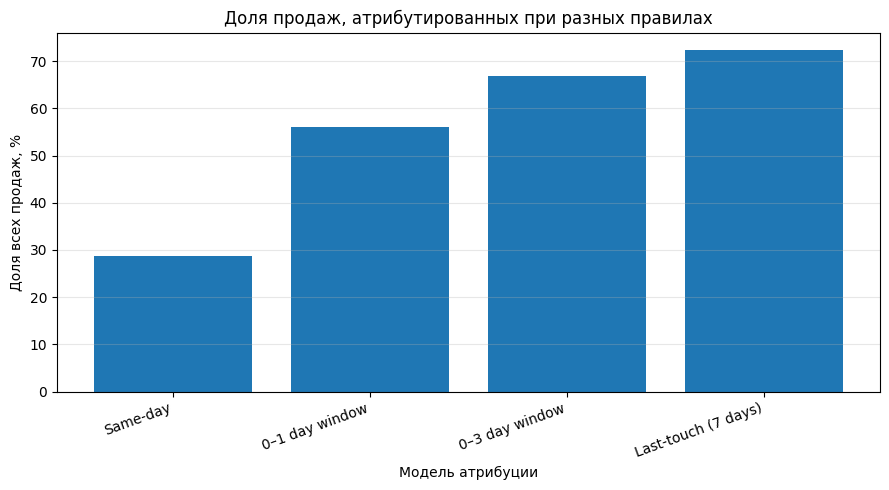

In [30]:
plt.figure(figsize=(9, 5))

plt.bar(
    attribution_model_comparison["model"],
    attribution_model_comparison["share_of_all_sales_pct"]
)

plt.title("Доля продаж, атрибутированных при разных правилах")
plt.xlabel("Модель атрибуции")
plt.ylabel("Доля всех продаж, %")

plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод по сравнению моделей атрибуции

Результат атрибуции существенно зависит от выбранного правила.

При same-day attribution маркетингу можно формально связать только 228 продаж,
или 28.7% от всех наблюдаемых продаж.

При расширении окна:

- до 1 дня доля возрастает до 56.0%;
- до 3 дней — до 66.8%;
- при last-touch в 7-дневном окне — до 72.5%.

Таким образом, оценка числа «атрибутированных» продаж меняется более чем в 2 раза
только из-за изменения attribution window.

Это подтверждает, что attribution не является измерением причинного эффекта.
Она представляет собой правило распределения заслуги за уже произошедшие продажи.

Поэтому результаты attribution необходимо интерпретировать только вместе
с явно заданной моделью и окном атрибуции.

## 3. Распределение last-touch attribution по типам активности

Теперь посмотрим, каким типам маркетинговой активности
last-touch модель приписывает продажи.

Last-touch выбирает последнее потенциальное маркетинговое касание
перед покупкой в пределах 7-дневного окна.

Важно: это не означает, что последнее событие вызвало покупку.
Это только правило атрибуции.

In [31]:
# Считаем, сколько продаж last-touch модель
# приписала каждому типу активности.

last_touch_by_activity = (
    last_touch
    .groupby("activity_type", as_index=False)
    .agg(
        attributed_sales=("sale_id", "nunique"),
        attributed_revenue=("amount", "sum")
    )
    .sort_values("attributed_sales", ascending=False)
)

# Доля от всех продаж, покрытых last-touch моделью
last_touch_by_activity["share_of_attributed_sales_pct"] = (
    last_touch_by_activity["attributed_sales"]
    / last_touch_count
    * 100
)

last_touch_by_activity

,activity_type,attributed_sales,attributed_revenue,share_of_attributed_sales_pct
1,Контент с предложением курсов,277,"2,173,143.50",48.09
3,Промо со скидкой,213,"1,309,313.17",36.98
2,Контент с упоминанием,49,"395,225.00",8.51
0,Запуск / набор,37,"284,462.50",6.42


In [32]:
# Смотрим, какие курсы получают больше всего
# last-touch атрибутированных продаж.

last_touch_by_course = (
    last_touch
    .groupby("course_normalized", as_index=False)
    .agg(
        attributed_sales=("sale_id", "nunique"),
        attributed_revenue=("amount", "sum")
    )
    .sort_values("attributed_sales", ascending=False)
)

last_touch_by_course

,course_normalized,attributed_sales,attributed_revenue
8,Аналитика про,93,"740,941.50"
0,AI-агенты про,91,"711,673.00"
3,ML про,90,"715,110.00"
9,Аналитика старт,70,"473,026.50"
7,Алгоритмы старт,60,"322,291.68"
1,Backend про,55,"438,342.50"
4,ML старт,49,"282,708.33"
6,Алгоритмы про,35,"268,409.00"
2,Backend старт,29,"183,741.66"
5,А/В-тесты,4,"25,900.00"


In [33]:
# Сравниваем внутренние и внешние размещения
# в рамках last-touch attribution.

last_touch_by_source = (
    last_touch
    .groupby("external_or_internal", as_index=False)
    .agg(
        attributed_sales=("sale_id", "nunique"),
        attributed_revenue=("amount", "sum")
    )
    .sort_values("attributed_sales", ascending=False)
)

last_touch_by_source

,external_or_internal,attributed_sales,attributed_revenue
0,external,395,"2,923,897.50"
1,internal,181,"1,238,246.67"


### Вывод по last-touch attribution

В модели last-touch большая часть атрибутированных продаж приходится
на два типа маркетинговой активности:

- контент с предложением курсов — 277 продаж (48.1%);
- промо со скидкой — 213 продаж (37.0%).

Контент с упоминанием и запуск / набор получают значительно меньшую долю
last-touch атрибуции.

Важно: это не означает, что контент с предложением курсов является
наиболее эффективным типом маркетинга.

Last-touch attribution показывает только то, какое потенциальное
маркетинговое событие было последним перед покупкой.
Результат зависит от частоты публикаций, их расположения во времени
и выбранного 7-дневного attribution window.

По курсам наибольшее количество last-touch продаж приходится
на «Аналитика про», «AI-агенты про» и «ML про».
Однако абсолютное число атрибутированных продаж нельзя напрямую
использовать для сравнения эффективности курсов,
поскольку общий объём продаж по курсам различается.

В разрезе источника 395 продаж были атрибутированы внешним размещениям,
а 181 — внутренним.

Этот результат также нельзя интерпретировать как доказательство
более высокой эффективности внешних размещений:
он может отражать разное количество и частоту маркетинговых событий.

## 4. Attribution rate по курсам и продуктовым линиям

Абсолютное число атрибутированных продаж нельзя напрямую использовать
для сравнения курсов, потому что общий объём продаж у них разный.

Поэтому рассчитаем attribution rate:

`last-touch attributed sales / все продажи курса`

Этот показатель показывает, какая доля продаж каждого курса
имеет хотя бы одно потенциальное маркетинговое касание в 7-дневном окне
и получает last-touch attribution.

Важно: высокий attribution rate не означает высокую эффективность маркетинга.
Он показывает только плотность связи продаж с маркетинговыми событиями
при выбранном правиле атрибуции.

In [34]:
# Общее число продаж по каждому курсу

course_sales_total = (
    sales
    .groupby("course_normalized", as_index=False)
    .agg(
        total_sales=("sale_id", "nunique"),
        total_revenue=("amount", "sum")
    )
)

course_sales_total.head()

,course_normalized,total_sales,total_revenue
0,AI-агенты про,91,"711,673.00"
1,Backend про,55,"438,342.50"
2,Backend старт,39,"263,396.66"
3,Data Engenering,4,"24,845.00"
4,Data Science,9,"69,295.00"


In [35]:
# Число last-touch атрибутированных продаж по каждому курсу

course_last_touch = (
    last_touch
    .groupby("course_normalized", as_index=False)
    .agg(
        attributed_sales=("sale_id", "nunique"),
        attributed_revenue=("amount", "sum")
    )
)

course_last_touch.head()

,course_normalized,attributed_sales,attributed_revenue
0,AI-агенты про,91,"711,673.00"
1,Backend про,55,"438,342.50"
2,Backend старт,29,"183,741.66"
3,ML про,90,"715,110.00"
4,ML старт,49,"282,708.33"


In [36]:
# Объединяем общий объём продаж и last-touch attribution

course_attribution_rate = (
    course_sales_total
    .merge(
        course_last_touch,
        on="course_normalized",
        how="left"
    )
)

# Курсы без last-touch касаний получают 0
course_attribution_rate[
    ["attributed_sales", "attributed_revenue"]
] = (
    course_attribution_rate[
        ["attributed_sales", "attributed_revenue"]
    ]
    .fillna(0)
)

# Доля продаж курса, покрытая last-touch моделью
course_attribution_rate["attribution_rate_pct"] = (
    course_attribution_rate["attributed_sales"]
    / course_attribution_rate["total_sales"]
    * 100
)

course_attribution_rate = (
    course_attribution_rate
    .sort_values("attribution_rate_pct", ascending=False)
)

course_attribution_rate

,course_normalized,total_sales,total_revenue,attributed_sales,attributed_revenue,attribution_rate_pct
0,AI-агенты про,91,"711,673.00",91.00,"711,673.00",100.00
5,ML про,90,"715,110.00",90.00,"715,110.00",100.00
11,Аналитика про,93,"740,941.50",93.00,"740,941.50",100.00
1,Backend про,55,"438,342.50",55.00,"438,342.50",100.00
9,Алгоритмы про,35,"268,409.00",35.00,"268,409.00",100.00
12,Аналитика старт,91,"641,616.50",70.00,"473,026.50",76.92
2,Backend старт,39,"263,396.66",29.00,"183,741.66",74.36
10,Алгоритмы старт,88,"529,851.68",60.00,"322,291.68",68.18
6,ML старт,80,"523,278.33",49.00,"282,708.33",61.25
7,А/В-тесты,8,"49,610.00",4.00,"25,900.00",50.00


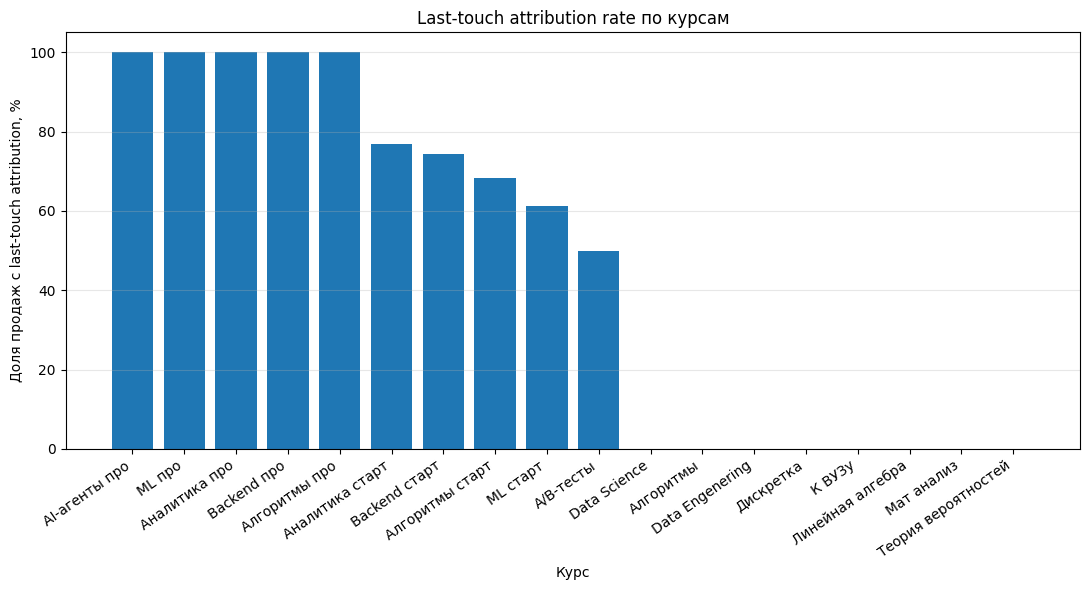

In [37]:
plt.figure(figsize=(11, 6))

plt.bar(
    course_attribution_rate["course_normalized"],
    course_attribution_rate["attribution_rate_pct"]
)

plt.title("Last-touch attribution rate по курсам")
plt.xlabel("Курс")
plt.ylabel("Доля продаж с last-touch attribution, %")

plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод

Last-touch attribution показывает, что покрытие маркетинговыми событиями
сильно различается между курсами.

Для ряда PRO-курсов каждая наблюдаемая продажа имела хотя бы одно
потенциальное маркетинговое касание за предыдущие 7 дней.

Для START-курсов доля таких продаж ниже и составляет примерно 60–77%.

Для некоторых курсов подходящие маркетинговые события в рассматриваемом окне
вообще отсутствуют, поэтому их продажи не получают last-touch attribution.

Важно: высокий attribution rate не означает высокий причинный эффект маркетинга.
Он показывает только то, насколько часто перед продажами курса присутствовали
маркетинговые события в выбранном 7-дневном окне.

## 5. Last-touch attribution rate: START vs PRO

Теперь сравним продуктовые линии START и PRO.

Для каждой линии считаем долю продаж, у которых найдено хотя бы одно
потенциальное маркетинговое событие за предыдущие 7 дней,
после чего last-touch модель выбирает последнее событие перед покупкой.

Важно: этот показатель не измеряет эффективность маркетинга.
Он показывает только, насколько плотно продажи линии связаны
с маркетинговыми событиями во времени.

In [38]:
# Определяем продуктовую линию по названию курса

def get_product_line(course):
    if pd.isna(course):
        return np.nan

    course_lower = course.lower()

    if "старт" in course_lower:
        return "START"

    if "про" in course_lower:
        return "PRO"

    return "OTHER"


sales["product_line_simple"] = (
    sales["course_normalized"]
    .apply(get_product_line)
)

last_touch["product_line_simple"] = (
    last_touch["course_normalized"]
    .apply(get_product_line)
)

In [39]:
# Общее число продаж по START и PRO

line_sales_total = (
    sales[
        sales["product_line_simple"].isin(["START", "PRO"])
    ]
    .groupby("product_line_simple", as_index=False)
    .agg(
        total_sales=("sale_id", "nunique"),
        total_revenue=("amount", "sum")
    )
)

# Число last-touch атрибутированных продаж

line_last_touch = (
    last_touch[
        last_touch["product_line_simple"].isin(["START", "PRO"])
    ]
    .groupby("product_line_simple", as_index=False)
    .agg(
        attributed_sales=("sale_id", "nunique"),
        attributed_revenue=("amount", "sum")
    )
)

line_attribution_rate = (
    line_sales_total
    .merge(
        line_last_touch,
        on="product_line_simple",
        how="left"
    )
)

# Доля продаж, покрытых last-touch моделью

line_attribution_rate["attribution_rate_pct"] = (
    line_attribution_rate["attributed_sales"]
    / line_attribution_rate["total_sales"]
    * 100
)

line_attribution_rate

,product_line_simple,total_sales,total_revenue,attributed_sales,attributed_revenue,attribution_rate_pct
0,PRO,364,"2,874,476.00",364,"2,874,476.00",100.00
1,START,298,"1,958,143.17",208,"1,261,768.17",69.80


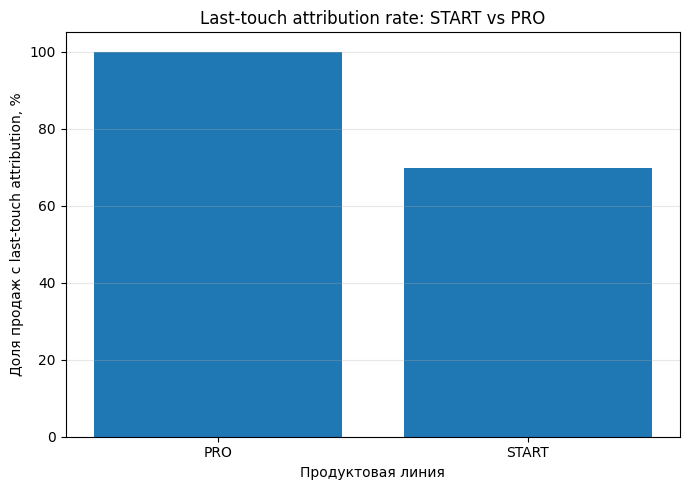

In [40]:
plt.figure(figsize=(7, 5))

plt.bar(
    line_attribution_rate["product_line_simple"],
    line_attribution_rate["attribution_rate_pct"]
)

plt.title("Last-touch attribution rate: START vs PRO")
plt.xlabel("Продуктовая линия")
plt.ylabel("Доля продаж с last-touch attribution, %")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод: START vs PRO

Last-touch attribution rate для PRO достигает 100%,
тогда как для START составляет около 70%.

Это не противоречит результатам event study.

Высокий attribution rate PRO означает, что практически перед каждой продажей
PRO в предыдущие 7 дней присутствовало хотя бы одно потенциальное
маркетинговое событие.

При этом event study показал, что продажи PRO меняются вокруг маркетинговых
дней относительно слабо и остаются более стабильными.

Для START ситуация обратная: маркетинговые события покрывают меньшую долю продаж,
но в периоды активного маркетинга наблюдается более выраженный краткосрочный
рост продаж.

Таким образом, PRO характеризуется более постоянным маркетинговым фоном,
тогда как START сильнее реагирует на отдельные маркетинговые периоды.

Важно: ни attribution rate, ни event study сами по себе
не доказывают причинный эффект маркетинга.

# 6. Приближённая оценка incrementality

Attribution отвечает на вопрос:

> «Какому маркетинговому событию формально приписать уже произошедшую продажу?»

Incrementality отвечает на другой вопрос:

> «Сколько продаж могло появиться дополнительно благодаря маркетингу
> сверх обычного уровня спроса?»

В идеальном случае для оценки incrementality нужна контрольная группа:
часть аудитории видит маркетинг, а сопоставимая часть — нет.

В исторических данных такой контрольной группы нет.

Поэтому далее используется приближённый подход:

`фактические продажи после маркетинга − ожидаемый baseline`

В качестве baseline используем среднее количество продаж
за три дня до маркетингового события: `D-3...D-1`.

Результат следует интерпретировать как оценку потенциального
инкрементального эффекта, а не как доказанный causal effect.

In [41]:
# Приводим время продажи к календарной дате

sales["date"] = sales["timestamp"].dt.floor("D")


# Агрегируем продажи на уровне:
# дата × курс

sales_daily = (
    sales
    .groupby(
        ["date", "course_normalized"],
        as_index=False
    )
    .agg(
        transactions=("sale_id", "nunique"),
        buyers=("student_id", "nunique"),
        revenue=("amount", "sum")
    )
)

sales_daily.head()

,date,course_normalized,transactions,buyers,revenue
0,2026-08-04,Backend старт,1,1,"8,745.00"
1,2026-08-04,Data Science,1,1,"15,695.00"
2,2026-08-04,ML про,2,2,"17,425.00"
3,2026-08-04,ML старт,1,1,"8,475.00"
4,2026-08-04,Аналитика старт,1,1,"7,890.00"


In [42]:
# Приводим маркетинговое событие к календарной дате

marketing_courses_overlap["date"] = (
    marketing_courses_overlap["event_time"]
    .dt.floor("D")
)


# Несколько событий могут относиться
# к одному курсу в один и тот же день.
#
# Поэтому объединяем их в одну строку date × course.

marketing_course_daily = (
    marketing_courses_overlap
    .groupby(
        ["date", "candidate_course"],
        as_index=False
    )
    .agg(
        marketing_events=("event_id", "nunique"),
        activity_types=(
            "activity_type",
            lambda x: " | ".join(
                sorted(set(x.dropna()))
            )
        )
    )
)

marketing_course_daily.head()

,date,candidate_course,marketing_events,activity_types
0,2026-07-01,Data science,1,Контент с предложением курсов
1,2026-07-01,ML старт,1,Контент с предложением курсов
2,2026-07-04,Backend старт,1,Промо со скидкой
3,2026-07-04,ML старт,2,Контент с предложением курсов | Промо со скидкой
4,2026-07-04,Алгоритмы старт,1,Промо со скидкой


## Логика baseline

Для каждого маркетингового дня по конкретному курсу считаем:

- `baseline` — среднее число продаж за D-3, D-2 и D-1;
- `D0` — продажи в день маркетинга;
- `D+1` — продажи на следующий день.

Затем оцениваем:

`Potential incremental sales D0 = D0 − baseline`

и

`Potential incremental sales D0-D+1 =
продажи D0 + продажи D+1 − 2 × baseline`

Вторая метрика учитывает, что краткосрочный эффект может сохраняться
не только в день публикации, но и на следующий день.

In [43]:
# Границы наблюдаемой истории продаж

sales_min_date = sales_daily["date"].min()
sales_max_date = sales_daily["date"].max()


incrementality_rows = []


for _, row in marketing_course_daily.iterrows():

    event_date = row["date"]
    course = row["candidate_course"]

    # Используем только события,
    # для которых полностью наблюдаем D-3...D+1.
    #
    # Иначе отсутствие данных можно ошибочно принять за 0 продаж.

    if (
        event_date - pd.Timedelta(days=3) < sales_min_date
        or event_date + pd.Timedelta(days=1) > sales_max_date
    ):
        continue


    # Продажи только нужного курса

    course_sales = sales_daily[
        sales_daily["course_normalized"] == course
    ]


    # Функция возвращает продажи и выручку
    # для конкретной календарной даты.
    #
    # Если дата находится внутри наблюдаемого периода,
    # но продаж не было, считаем 0.

    def get_day_metrics(target_date):

        day = course_sales[
            course_sales["date"] == target_date
        ]

        if len(day) == 0:
            return 0, 0

        return (
            day["transactions"].sum(),
            day["revenue"].sum()
        )


    # D-3, D-2, D-1

    baseline_transactions = []
    baseline_revenue = []

    for lag in [-3, -2, -1]:

        tx, rev = get_day_metrics(
            event_date + pd.Timedelta(days=lag)
        )

        baseline_transactions.append(tx)
        baseline_revenue.append(rev)


    # Средний дневной baseline

    baseline_tx = np.mean(
        baseline_transactions
    )

    baseline_rev = np.mean(
        baseline_revenue
    )


    # D0

    d0_tx, d0_rev = get_day_metrics(
        event_date
    )


    # D+1

    d1_tx, d1_rev = get_day_metrics(
        event_date + pd.Timedelta(days=1)
    )


    # Приближённый incremental effect в D0

    incremental_d0_tx = (
        d0_tx - baseline_tx
    )

    incremental_d0_rev = (
        d0_rev - baseline_rev
    )


    # Приближённый incremental effect
    # суммарно за D0 + D+1

    incremental_01_tx = (
        d0_tx
        + d1_tx
        - 2 * baseline_tx
    )

    incremental_01_rev = (
        d0_rev
        + d1_rev
        - 2 * baseline_rev
    )


    incrementality_rows.append({

        "event_date": event_date,
        "candidate_course": course,
        "activity_types": row["activity_types"],
        "marketing_events": row["marketing_events"],

        "baseline_transactions": baseline_tx,
        "d0_transactions": d0_tx,
        "d1_transactions": d1_tx,

        "potential_incremental_d0_transactions":
            incremental_d0_tx,

        "potential_incremental_01_transactions":
            incremental_01_tx,

        "baseline_revenue": baseline_rev,
        "d0_revenue": d0_rev,
        "d1_revenue": d1_rev,

        "potential_incremental_d0_revenue":
            incremental_d0_rev,

        "potential_incremental_01_revenue":
            incremental_01_rev,
    })


incrementality = pd.DataFrame(
    incrementality_rows
)

incrementality.head()

,event_date,candidate_course,activity_types,marketing_events,baseline_transactions,d0_transactions,d1_transactions,potential_incremental_d0_transactions,potential_incremental_01_transactions,baseline_revenue,d0_revenue,d1_revenue,potential_incremental_d0_revenue,potential_incremental_01_revenue
0,2026-08-07,ML про,Контент с упоминанием,1,0.67,1,1,0.33,0.67,"5,808.33","8,745.00","8,745.00","2,936.67","5,873.33"
1,2026-08-07,Алгоритмы старт,Контент с упоминанием,1,0.00,0,14,0.00,14.00,0.00,0.00,"72,565.00",0.00,"72,565.00"
2,2026-08-08,Backend старт,Промо со скидкой,4,1.00,8,12,7.00,18.00,"8,308.33","45,850.00","67,226.66","37,541.67","96,459.99"
3,2026-08-08,ML старт,Промо со скидкой,5,1.00,9,20,8.00,27.00,"8,411.67","48,130.00","107,298.33","39,718.33","138,605.00"
4,2026-08-08,Алгоритмы старт,Промо со скидкой,5,0.00,14,28,14.00,42.00,0.00,"72,565.00","142,186.68","72,565.00","214,751.68"


In [44]:
incrementality[
    [
        "event_date",
        "candidate_course",
        "baseline_transactions",
        "d0_transactions",
        "d1_transactions",
        "potential_incremental_d0_transactions",
        "potential_incremental_01_transactions"
    ]
].head(20)

,event_date,candidate_course,baseline_transactions,d0_transactions,d1_transactions,potential_incremental_d0_transactions,potential_incremental_01_transactions
0,2026-08-07,ML про,0.67,1,1,0.33,0.67
1,2026-08-07,Алгоритмы старт,0.00,0,14,0.00,14.00
2,2026-08-08,Backend старт,1.00,8,12,7.00,18.00
3,2026-08-08,ML старт,1.00,9,20,8.00,27.00
4,2026-08-08,Алгоритмы старт,0.00,14,28,14.00,42.00
5,2026-08-08,Аналитика старт,0.00,7,17,7.00,24.00
6,2026-08-09,Backend старт,2.67,12,2,9.33,8.67
7,2026-08-09,ML старт,3.33,20,4,16.67,17.33
8,2026-08-09,Алгоритмы старт,4.67,28,7,23.33,25.67
9,2026-08-09,Аналитика старт,2.33,17,11,14.67,23.33


In [45]:
# Общая описательная статистика
# потенциального incremental effect

incrementality[
    [
        "potential_incremental_d0_transactions",
        "potential_incremental_01_transactions",
        "potential_incremental_d0_revenue",
        "potential_incremental_01_revenue"
    ]
].describe()

,potential_incremental_d0_transactions,potential_incremental_01_transactions,potential_incremental_d0_revenue,potential_incremental_01_revenue
count,114.00,114.00,114.00,114.00
mean,1.10,1.64,"6,785.87","9,463.17"
std,5.01,9.34,"33,739.34","62,259.98"
min,-8.33,-18.00,"-67,191.67","-144,108.33"
25%,-1.33,-2.92,"-10,093.92","-22,306.25"
50%,0.00,0.00,0.00,-170.58
75%,2.00,4.25,"18,220.00","37,383.33"
max,23.33,42.00,"152,875.00","214,751.68"


In [46]:
incrementality_summary = pd.DataFrame({

    "metric": [
        "D0 transactions",
        "D0-D+1 transactions",
        "D0 revenue",
        "D0-D+1 revenue"
    ],

    "average_potential_incremental": [

        incrementality[
            "potential_incremental_d0_transactions"
        ].mean(),

        incrementality[
            "potential_incremental_01_transactions"
        ].mean(),

        incrementality[
            "potential_incremental_d0_revenue"
        ].mean(),

        incrementality[
            "potential_incremental_01_revenue"
        ].mean(),
    ]
})

incrementality_summary

,metric,average_potential_incremental
0,D0 transactions,1.10
1,D0-D+1 transactions,1.64
2,D0 revenue,"6,785.87"
3,D0-D+1 revenue,"9,463.17"


In [47]:
# Проверяем, в какой доле маркетинговых периодов
# D0 оказался выше baseline.

incrementality["d0_above_baseline"] = (
    incrementality[
        "potential_incremental_d0_transactions"
    ] > 0
)


incrementality["d01_above_baseline"] = (
    incrementality[
        "potential_incremental_01_transactions"
    ] > 0
)


print(
    "Доля событий с D0 выше baseline:",
    f"{incrementality['d0_above_baseline'].mean() * 100:.1f}%"
)

print(
    "Доля событий с D0-D+1 выше ожидаемого baseline:",
    f"{incrementality['d01_above_baseline'].mean() * 100:.1f}%"
)

Доля событий с D0 выше baseline: 44.7%
Доля событий с D0-D+1 выше ожидаемого baseline: 42.1%


### Вывод по приближённой incrementality estimate

В среднем в день маркетингового события наблюдается примерно на 1.1 продажи
больше локального baseline, а суммарно за D0–D+1 — примерно на 1.6 продажи больше.

Средняя дополнительная выручка относительно baseline составляет около
6.8 тыс. ₽ в D0 и 9.5 тыс. ₽ за D0–D+1.

Однако рост наблюдается далеко не для большинства маркетинговых периодов:

- только 44.7% событий имеют D0 выше baseline;
- только 42.1% событий имеют D0–D+1 выше ожидаемого уровня.

Это означает, что положительное среднее значение, вероятно,
формируется за счёт ограниченного числа более сильных маркетинговых периодов.

Поэтому средний uplift нельзя интерпретировать как эффект
«типичного» маркетингового события.

Кроме того, локальный baseline не является полноценным counterfactual:
он не учитывает прогрев, пересечение кампаний, сезонность и другие факторы.

Следовательно, расчёт отражает потенциальный incremental uplift,
но не доказанный причинный эффект маркетинга.